# Heart Disease Risk Classification from Tabular Clinical Features

## Business use case

A binary risk model can support clinical triage, retrospective cohort analysis, or prioritization of patients for additional review. In a healthcare setting, the model should be treated as decision support rather than a stand-alone diagnosis.

## Objective

The notebook builds a neural network that predicts the binary `target` from a mix of numerical and categorical clinical variables. The workflow emphasizes leakage-safe preprocessing, stratified evaluation, and comparison against the class-distribution baseline.

## Result in context

The saved test evaluation reports **80.33% accuracy**. The majority-class baseline is about **72.61%**, so the neural network improves meaningfully over simply predicting the most common class.


## Step 1 — Load and inspect the clinical dataset

The dataset is loaded from TensorFlow's public storage. Shape, sample rows, and target prevalence are inspected before modeling so the class balance and feature types are explicit.


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

In [ ]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [ ]:
df.shape

(303, 14)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


## Step 2 — Encode categorical variables and normalize numeric features

Categorical columns are one-hot encoded. The target is separated, then the data is split with stratification. Means and standard deviations are computed from the training set only and reused for the test set, which avoids leaking test information into preprocessing.


In [ ]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

In [ ]:
df = pd.get_dummies(df, columns = categorical_variables)

In [ ]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
df.target.value_counts(normalize=True)

,proportion
target,
0,0.726073
1,0.273927


In [ ]:
y = df.pop('target')

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(df, y, test_size=0.2, stratify=y, random_state = 42)

In [ ]:
means = train_X[numerics].mean()
sd = train_X[numerics].std()

In [ ]:
means

,0
age,54.698347
trestbps,131.954545
chol,248.921488
thalach,148.504132
oldpeak,1.078099
slope,1.582645


In [ ]:
train_X[numerics]= (train_X[numerics] - means)/sd

In [ ]:
test_X[numerics]= (test_X[numerics] - means)/sd

In [ ]:
train_X.head()

,age,trestbps,chol,thalach,oldpeak,slope,sex_0,sex_1,cp_0,cp_1,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
180,2.146720,-0.682081,0.373261,-1.172451,-0.740863,-0.938703,True,False,False,False,...,True,False,True,False,False,False,False,False,True,False
99,-0.300109,1.143718,0.912372,1.257355,0.102849,0.672404,False,True,False,True,...,False,True,False,False,False,False,False,False,False,True
190,0.700867,0.116706,-0.277391,-0.149375,1.284047,0.672404,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False
110,2.480378,-0.396800,1.023913,0.575304,-0.909606,-0.938703,False,True,False,False,...,True,False,False,False,True,False,False,False,True,False
116,-2.190840,-0.339744,0.614932,0.319535,-0.909606,-0.938703,False,True,False,False,...,True,True,False,False,False,False,False,False,False,True


In [ ]:
train_X = train_X.to_numpy().astype(np.float32)
test_X = test_X.to_numpy().astype(np.float32)

In [ ]:
train_X.shape, train_y.shape

((242, 29), (242,))

In [ ]:
test_X.shape, test_y.shape


((61, 29), (61,))

## Step 3 — Define the neural network

A small dense network is used for this tabular binary-classification problem. The input width is derived from the processed feature matrix and the output uses a sigmoid unit.


In [ ]:
num_columns = train_X.shape[1]

# define the input layer
input = keras.Input(shape=(num_columns,))

# feed the input vector to the hidden layer
h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)

# feed the output of the hidden layer to the output layer
output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)

# tell Keras that this (input,output) pair is your model
model = keras.Model(input, output)

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

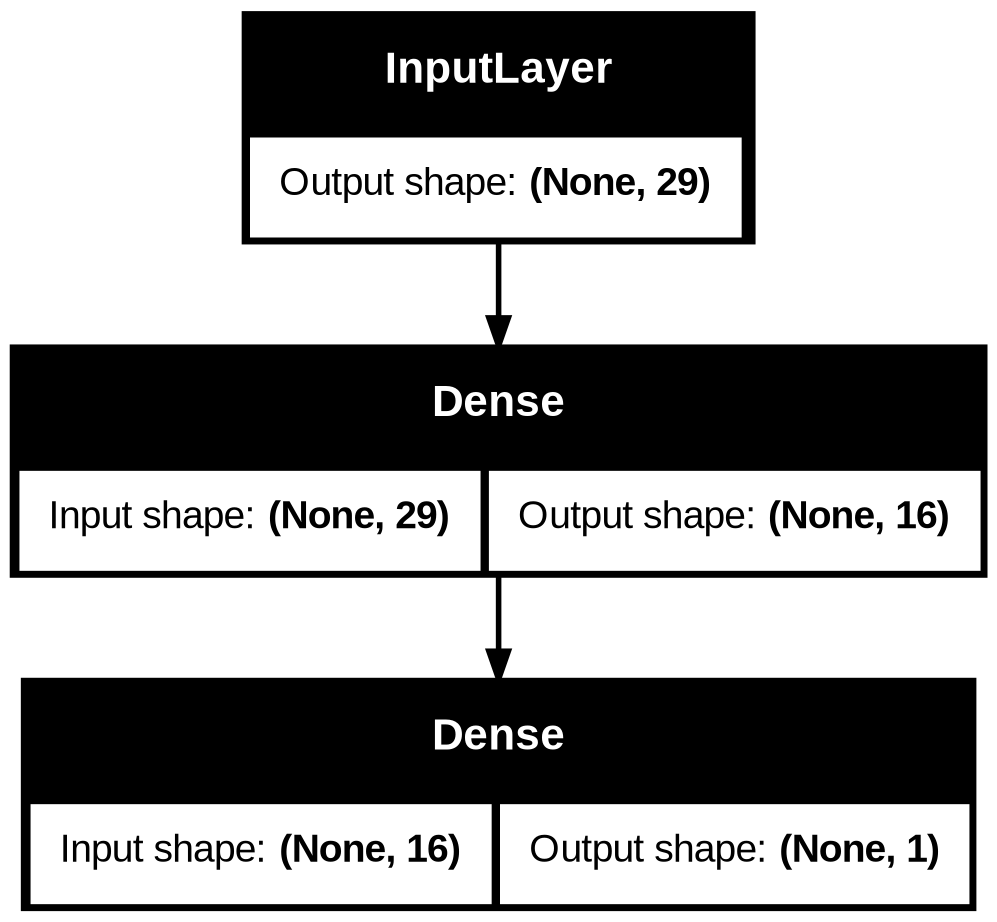

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
(29 * 16 + 16) + (16 * 1 + 1)

497

## Step 4 — Train while monitoring validation behavior

The model is compiled with Adam, binary cross-entropy, and accuracy. Training history is stored so train and validation loss/accuracy can be inspected for underfitting or overfitting.


In [ ]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
history = model.fit(train_X,
                    train_y,
                    epochs=160,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9689 - loss: 0.1029 - val_accuracy: 0.8571 - val_loss: 0.3075
Epoch 2/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9741 - loss: 0.1025 - val_accuracy: 0.8571 - val_loss: 0.3076
Epoch 3/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9741 - loss: 0.1020 - val_accuracy: 0.8571 - val_loss: 0.3086
Epoch 4/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9741 - loss: 0.1016 - val_accuracy: 0.8571 - val_loss: 0.3091
Epoch 5/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9741 - loss: 0.1012 - val_accuracy: 0.8571 - val_loss: 0.3092
Epoch 6/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9741 - loss: 0.1008 - val_accuracy: 0.8571 - val_loss: 0.3090
Epoch 7/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9741 - loss: 0.1004 - val_accuracy: 0.8571 - val_loss: 0.3095
Epoch 8/160
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9741 - loss: 0.0999 - val_accuracy: 0.8571 - val_loss:

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

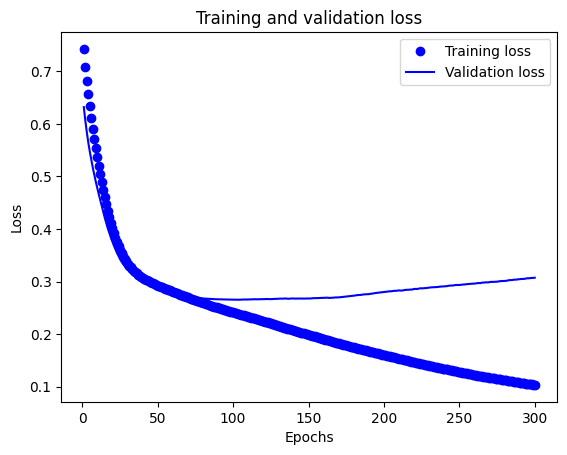

In [ ]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

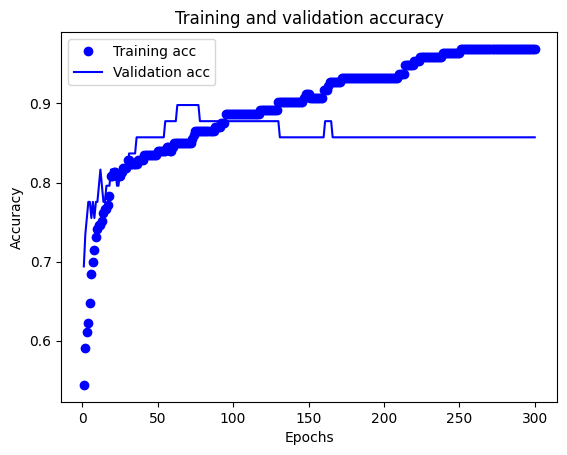

In [ ]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Step 5 — Evaluate against a practical baseline

The held-out test set provides the main performance estimate. The class proportions are also printed so the model can be judged against the accuracy of an always-majority prediction.


In [ ]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8033 - loss: 0.7035


[0.7035040855407715, 0.8032786846160889]

In [ ]:
y.value_counts(normalize=True)

,proportion
target,
0,0.726073
1,0.273927


## Technical conclusions

The network reaches **80.33% test accuracy**, compared with a majority-class baseline of roughly **72.61%**. That gap shows useful signal in the processed clinical features. Accuracy alone is not enough for a medical classification task, though; sensitivity, specificity, ROC-AUC, calibration, and the cost of false negatives would be necessary for a serious model review.

The preprocessing design is a strength of the notebook: numeric normalization uses training statistics and the split is stratified. For a next iteration, I would add probability calibration, threshold analysis, repeated cross-validation, and an interpretable baseline such as logistic regression.

## Business conclusions

The model could be useful as a screening or prioritization signal if it is validated on the population where it will be used. The business value would come from helping clinicians or care teams focus attention, not from automating diagnosis. Any deployment would also require clinical governance, fairness checks, and monitoring for population drift.

## Limitations and next steps

This is a small benchmark dataset, and the notebook does not report subgroup performance or clinical operating points. External validation and clinically meaningful error metrics are the next priorities.
